# Customer Churn Prediction

| Property | Detail |
|----------|--------|
| **Dataset** | IBM Telco Customer Churn (Kaggle) |
| **Records** | 7,043 customers × 21 columns |
| **Target** | `Churn` (Yes = Churned, No = Stayed) |
| **Churn Rate** | 26.5% — Realistic class imbalance |
| **Models** | Logistic Regression · Decision Tree · Random Forest · Gradient Boosting |


In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)


#### 1. Load Dataset

In [3]:
df = pd.read_csv('telco_churn.csv')
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')

df.head()

  Rows    : 7,043
  Columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print('\n Column Types:')
df.info()
print('\n Statistical Summary:')
df.describe()


 Column Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Churn Distribution:
  Stayed  (No) : 5,174  (73.5%)
  Churned (Yes): 1,869  (26.5%)

 Class Imbalance detected


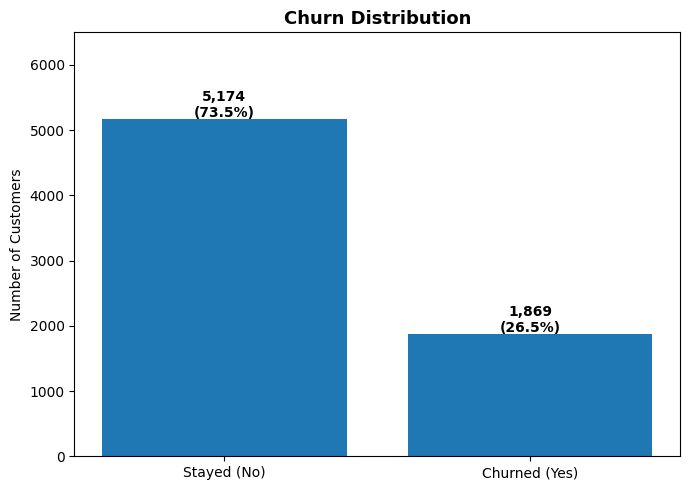

In [5]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()

print('\nChurn Distribution:')
print(f'  Stayed  (No) : {churn_counts["No"]:,}  ({churn_counts["No"]/len(df)*100:.1f}%)')
print(f'  Churned (Yes): {churn_counts["Yes"]:,}  ({churn_counts["Yes"]/len(df)*100:.1f}%)')
print('\n Class Imbalance detected')

plt.figure(figsize=(7, 5))

bars = plt.bar(['Stayed (No)', 'Churned (Yes)'], churn_counts.values)

for bar, val in zip(bars, churn_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.title('Churn Distribution', fontweight='bold', fontsize=13)
plt.ylabel('Number of Customers')
plt.ylim(0, 6500)

plt.tight_layout()
plt.show()

####  2. Exploratory Data Analysis (EDA)


In [ ]:
#null value count
print("\nNull Value Count:\n", df.isnull().sum())
print("\nTotal NaN:", df.isnull().sum().sum())

blank_tc = (df['TotalCharges'].str.strip() == '').sum()
print("\nBlank Strings in TotalCharges:", blank_tc)
print("Affected Rows:")
print(df[df['TotalCharges'].str.strip() == ''][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])



Null Value Count:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total NaN: 0

Blank Strings in TotalCharges: 11
Affected Rows:
      tenure  MonthlyCharges TotalCharges Churn
488        0           52.55                 No
753        0           20.25                 No
936        0           80.85                 No
1082       0           25.75                 No
1340       0           56.05                 No
3331       0           19.85                 No
3826       0           25.35                 No
4380       0           20.00                 No
5218     

In [7]:
# Categorical Columns 

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'TotalCharges', 'Churn']]

print("\nCategorical Column Unique Values:")
for col in cat_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

#Churn Rate by Key Categorical Features

print("\nChurn Rate by Contract Type:")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Internet Service:")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Payment Method:")
print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Senior Citizen:")
print(df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Gender:")
print(df.groupby('gender')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Partner:")
print(df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Dependents:")
print(df.groupby('Dependents')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Tech Support:")
print(df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Online Security:")
print(df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)

print("\nChurn Rate by Paperless Billing:")
print(df.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True).unstack().round(4) * 100)



Categorical Column Unique Values:
  gender: ['Female', 'Male']
  Partner: ['Yes', 'No']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  MultipleLines: ['No phone service', 'No', 'Yes']
  InternetService: ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: ['No', 'Yes', 'No internet service']
  OnlineBackup: ['Yes', 'No', 'No internet service']
  DeviceProtection: ['No', 'Yes', 'No internet service']
  TechSupport: ['No', 'Yes', 'No internet service']
  StreamingTV: ['No', 'Yes', 'No internet service']
  StreamingMovies: ['No', 'Yes', 'No internet service']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: ['Yes', 'No']
  PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

Churn Rate by Contract Type:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

Churn Rate by Internet Service:
Churn               No

In [8]:
# Numeric Feature Analysis

tc_numeric = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

print("\nTenure Stats:")
print(df['tenure'].describe().round(2))

print("\nMonthly Charges Stats:")
print(df['MonthlyCharges'].describe().round(2))

print("\nTotal Charges Stats (excluding blanks):")
print(tc_numeric.describe().round(2))

print("\nMean Tenure by Churn:")
print(df.groupby('Churn')['tenure'].mean().round(2))

print("\nMean Monthly Charges by Churn:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

print("\nMean Total Charges by Churn:")
temp = df.copy()
temp['TotalCharges'] = tc_numeric
print(temp.groupby('Churn')['TotalCharges'].mean().round(2))



Tenure Stats:
count    7043.00
mean       32.37
std        24.56
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00
Name: tenure, dtype: float64

Monthly Charges Stats:
count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: MonthlyCharges, dtype: float64

Total Charges Stats (excluding blanks):
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80
Name: TotalCharges, dtype: float64

Mean Tenure by Churn:
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

Mean Monthly Charges by Churn:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

Mean Total Charges by Churn:
Churn
No     2555.34
Yes    1531.80
Name: TotalCharges, dtype: float64


In [ ]:
# Duplicate Check

dup_count = df.drop(columns=['customerID']).duplicated().sum()
print("\nDuplicate Rows (excluding customerID):", dup_count)

print("\nCustomerID Unique Count:", df['customerID'].nunique(), "| Total Rows:", len(df))



Duplicate Rows (excluding customerID): 22

CustomerID Unique Count: 7043 | Total Rows: 7043


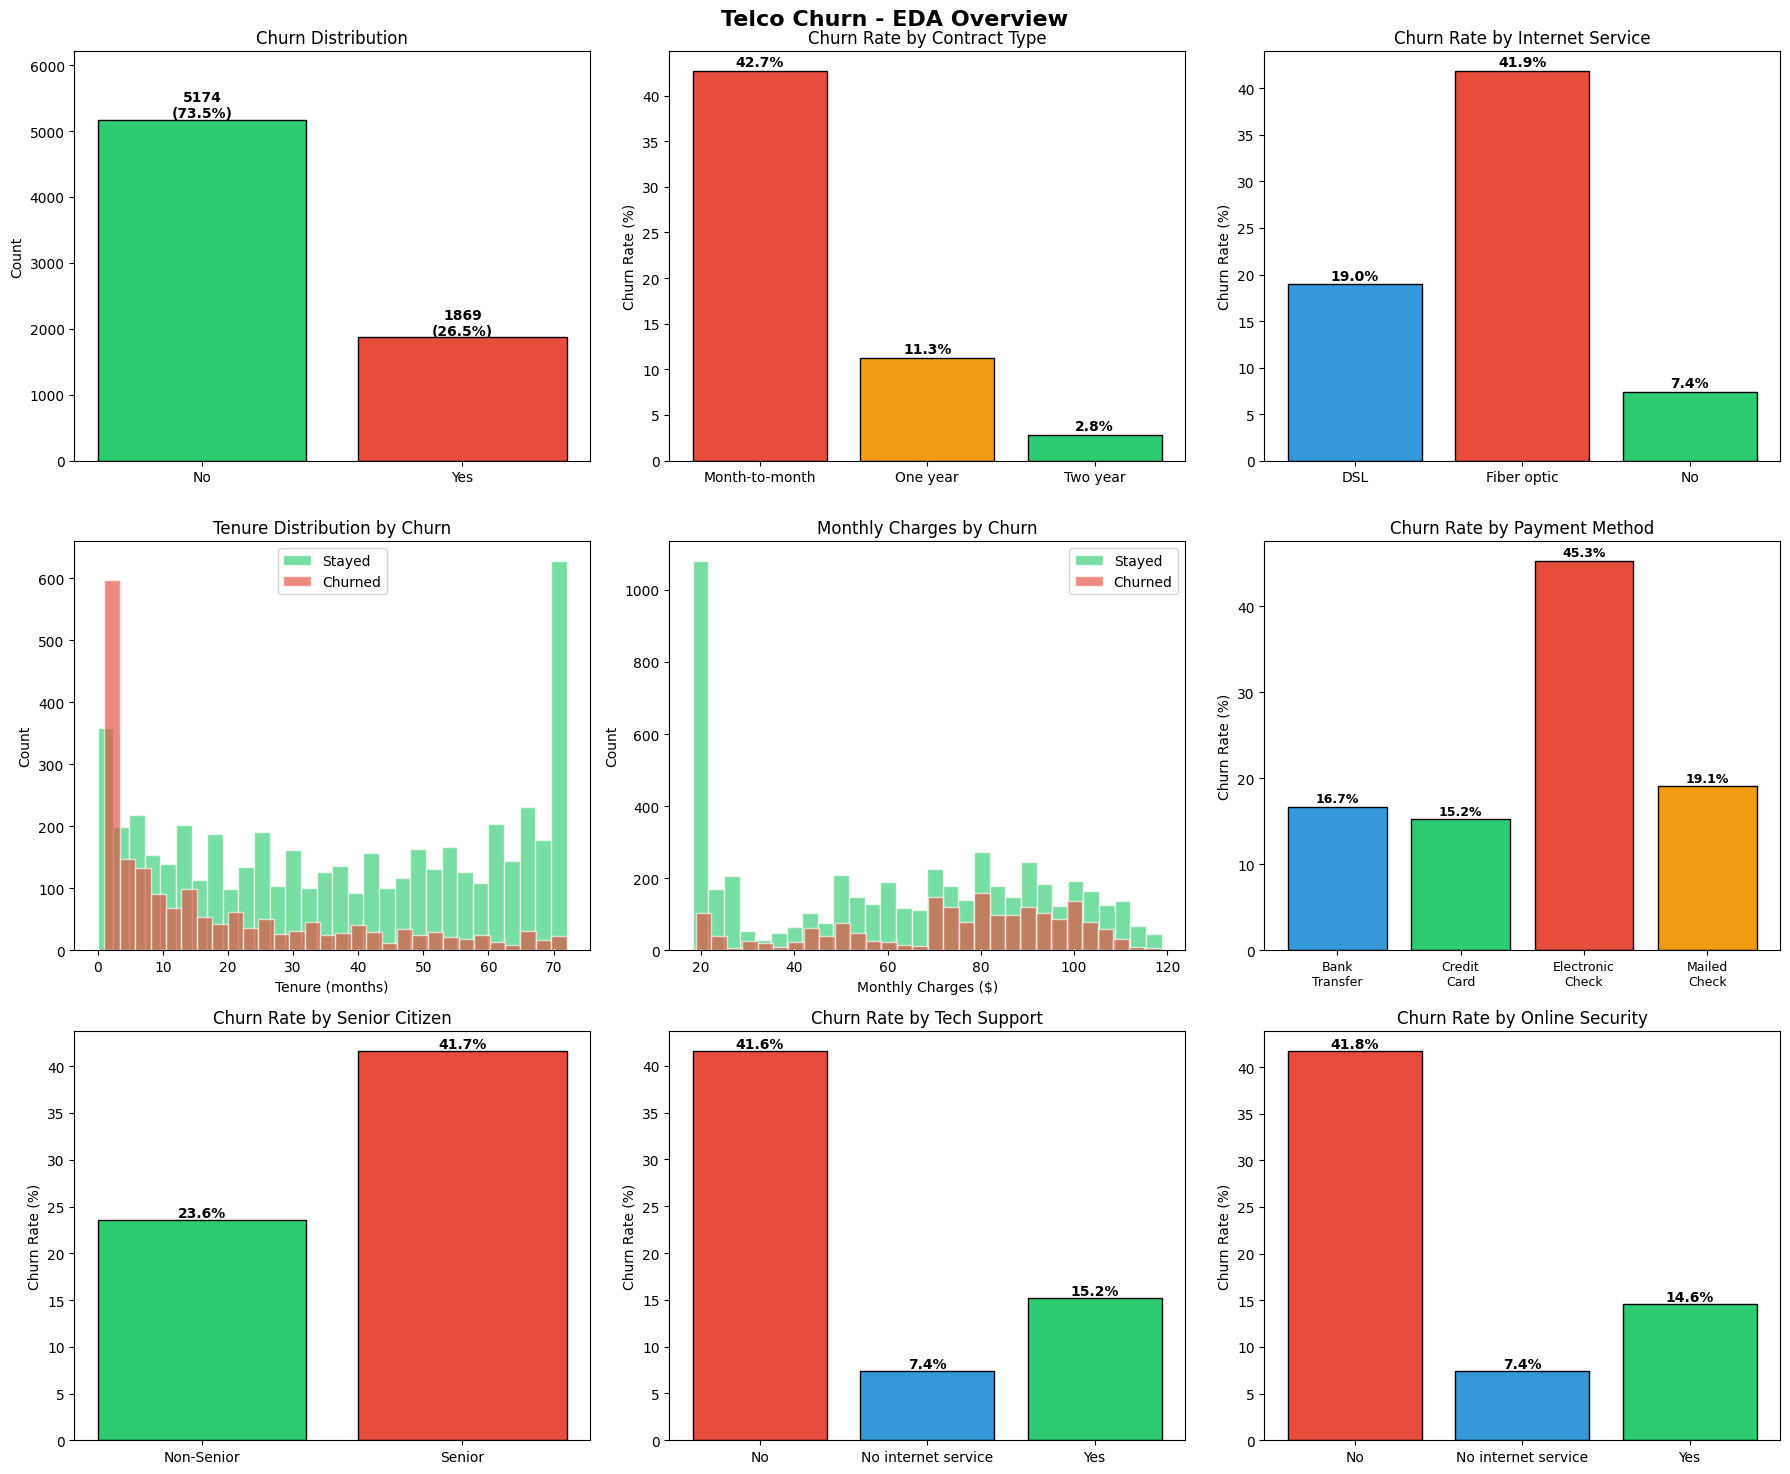

In [ ]:
# EDA Visualizations 

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Telco Churn - EDA Overview', fontsize=16, fontweight='bold')

# Plot 1: Churn Distribution
bars = axes[0, 0].bar(churn_counts.index, churn_counts.values,
                      color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 0].set_title('Churn Distribution')
axes[0, 0].set_ylabel('Count')
for bar, val in zip(bars, churn_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, val + 40,
                    f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0, 0].set_ylim(0, max(churn_counts.values) * 1.2)

# Plot 2: Churn Rate by Contract
contract_rate = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[0, 1].bar(contract_rate.index, contract_rate.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[0, 1].set_title('Churn Rate by Contract Type')
axes[0, 1].set_ylabel('Churn Rate (%)')
for i, val in enumerate(contract_rate.values):
    axes[0, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Plot 3: Churn Rate by Internet Service
internet_rate = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[0, 2].bar(internet_rate.index, internet_rate.values,
               color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0, 2].set_title('Churn Rate by Internet Service')
axes[0, 2].set_ylabel('Churn Rate (%)')
for i, val in enumerate(internet_rate.values):
    axes[0, 2].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Plot 4: Tenure Distribution by Churn
axes[1, 0].hist(df[df['Churn'] == 'No']['tenure'], bins=30, alpha=0.65,
                color='#2ecc71', label='Stayed', edgecolor='white')
axes[1, 0].hist(df[df['Churn'] == 'Yes']['tenure'], bins=30, alpha=0.65,
                color='#e74c3c', label='Churned', edgecolor='white')
axes[1, 0].set_title('Tenure Distribution by Churn')
axes[1, 0].set_xlabel('Tenure (months)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# Plot 5: Monthly Charges Distribution by Churn
axes[1, 1].hist(df[df['Churn'] == 'No']['MonthlyCharges'], bins=30, alpha=0.65,
                color='#2ecc71', label='Stayed', edgecolor='white')
axes[1, 1].hist(df[df['Churn'] == 'Yes']['MonthlyCharges'], bins=30, alpha=0.65,
                color='#e74c3c', label='Churned', edgecolor='white')
axes[1, 1].set_title('Monthly Charges by Churn')
axes[1, 1].set_xlabel('Monthly Charges ($)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

# Plot 6: Churn Rate by Payment Method
pay_rate = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
short_labels = ['Bank\nTransfer', 'Credit\nCard', 'Electronic\nCheck', 'Mailed\nCheck']
axes[1, 2].bar(range(len(pay_rate)), pay_rate.values,
               color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black')
axes[1, 2].set_xticks(range(len(pay_rate)))
axes[1, 2].set_xticklabels(short_labels, fontsize=9)
axes[1, 2].set_title('Churn Rate by Payment Method')
axes[1, 2].set_ylabel('Churn Rate (%)')
for i, val in enumerate(pay_rate.values):
    axes[1, 2].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Plot 7: Senior Citizen Churn Rate
senior_rate = df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[2, 0].bar(['Non-Senior', 'Senior'], senior_rate.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[2, 0].set_title('Churn Rate by Senior Citizen')
axes[2, 0].set_ylabel('Churn Rate (%)')
for i, val in enumerate(senior_rate.values):
    axes[2, 0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

# Plot 8: Churn Rate by Tech Support
ts_rate = df.groupby('TechSupport')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[2, 1].bar(ts_rate.index, ts_rate.values,
               color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
axes[2, 1].set_title('Churn Rate by Tech Support')
axes[2, 1].set_ylabel('Churn Rate (%)')
for i, val in enumerate(ts_rate.values):
    axes[2, 1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

# Plot 9: Churn Rate by Online Security
os_rate = df.groupby('OnlineSecurity')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[2, 2].bar(os_rate.index, os_rate.values,
               color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
axes[2, 2].set_title('Churn Rate by Online Security')
axes[2, 2].set_ylabel('Churn Rate (%)')
for i, val in enumerate(os_rate.values):
    axes[2, 2].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### 3. Clean Dataset


In [14]:
# Check missing values
print('\n Missing Value Check:')
print(df.isnull().sum())
print(f'\n  Total NaN values: {df.isnull().sum().sum()}')
print('\nTotalCharges has HIDDEN missing values — blank spaces stored as text!')
blank_check = (df['TotalCharges'].str.strip() == '').sum()
print(f'   Blank spaces in TotalCharges: {blank_check}')


# Converting TotalCharges
df_clean = df.copy()

df_clean['TotalCharges'] = df_clean['TotalCharges'].str.strip()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

median_tc = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_tc)

print(f'   TotalCharges fixed:')
print(f'   Dtype before: object (string)')
print(f'   Dtype after : {df_clean["TotalCharges"].dtype}')
print(f'   11 blank values filled with median = {median_tc:.2f}')
print(f'   Remaining NaN: {df_clean["TotalCharges"].isnull().sum()}')


# Convert Churn Yes/No → 1/0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
print(f' Churn converted: Yes→1, No→0')
print(f' Churn value counts: {df_clean["Churn"].value_counts().to_dict()}')


# Drop customerID
df_clean = df_clean.drop(columns=['customerID'])
print(f' customerID dropped')

# Remove duplicates
dups = df_clean.duplicated().sum()
print(f'\n Duplicate rows found: {dups}')
print('   Retaining duplicates — different customers can have same profile')

print(f'\n Final clean shape: {df_clean.shape}')
print(f'   Features: {df_clean.shape[1]-1} | Target: Churn')



 Missing Value Check:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

  Total NaN values: 0

TotalCharges has HIDDEN missing values — blank spaces stored as text!
   Blank spaces in TotalCharges: 11
   TotalCharges fixed:
   Dtype before: object (string)
   Dtype after : float64
   11 blank values filled with median = 1397.47
   Remaining NaN: 0
 Churn converted: Yes→1, No→0
 Churn value counts: {0: 5174, 1: 1869}
 customerID dropped

 Duplicate rows found: 22
   Retaining duplicates — different customers can have same profile

 Final clean shape: (7043, 20)
   Fea

Implementations done in data cleaning  
1. `TotalCharges` is stored as string now converted into numeric
2. `TotalCharges` has 11 blank spaces that has been treated as missing values now filled with median value
3. `Churn` is Yes/No string — has been converted to 1/0
4. `customerID` has been be dropped (identifier, not a feature)
5.  22 duplicate rows identified and retained

#### 4.Encode Categorical Variables


Strategy:
- Label Encoding → Binary columns (only 2 unique values like Yes/No, Male/Female)
- One-Hot Encoding → Multi-class columns (3+ unique values like Contract type)

In [15]:
# Identify categorical columns
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)} total):')
for col in cat_cols:
    unique_vals = df_clean[col].unique()
    print(f'  {col:<22}: {len(unique_vals)} unique → {list(unique_vals)[:4]}')
df_encoded = df_clean.copy()

# Label Encoding — binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']
le = LabelEncoder()
le_mappings = {}
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('Label Encoding Applied:')
for col, mapping in le_mappings.items():
    print(f'  {col:<20}: {mapping}')

# One-Hot Encoding — multi-class columns
multi_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies', 'Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=False)

# Convert bool to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'\n One-Hot Encoding Applied to: {multi_cols}')
print(f'\n Shape after encoding:')
print(f'   Before: (7043, 20)  →  After: {df_encoded.shape}')
print(f'   Features expanded from 19 → {df_encoded.shape[1]-1} (due to one-hot columns)')
    


Categorical columns (15 total):
  gender                : 2 unique → ['Female', 'Male']
  Partner               : 2 unique → ['Yes', 'No']
  Dependents            : 2 unique → ['No', 'Yes']
  PhoneService          : 2 unique → ['No', 'Yes']
  MultipleLines         : 3 unique → ['No phone service', 'No', 'Yes']
  InternetService       : 3 unique → ['DSL', 'Fiber optic', 'No']
  OnlineSecurity        : 3 unique → ['No', 'Yes', 'No internet service']
  OnlineBackup          : 3 unique → ['Yes', 'No', 'No internet service']
  DeviceProtection      : 3 unique → ['No', 'Yes', 'No internet service']
  TechSupport           : 3 unique → ['No', 'Yes', 'No internet service']
  StreamingTV           : 3 unique → ['No', 'Yes', 'No internet service']
  StreamingMovies       : 3 unique → ['No', 'Yes', 'No internet service']
  Contract              : 3 unique → ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling      : 2 unique → ['Yes', 'No']
  PaymentMethod         : 4 unique → ['Electron

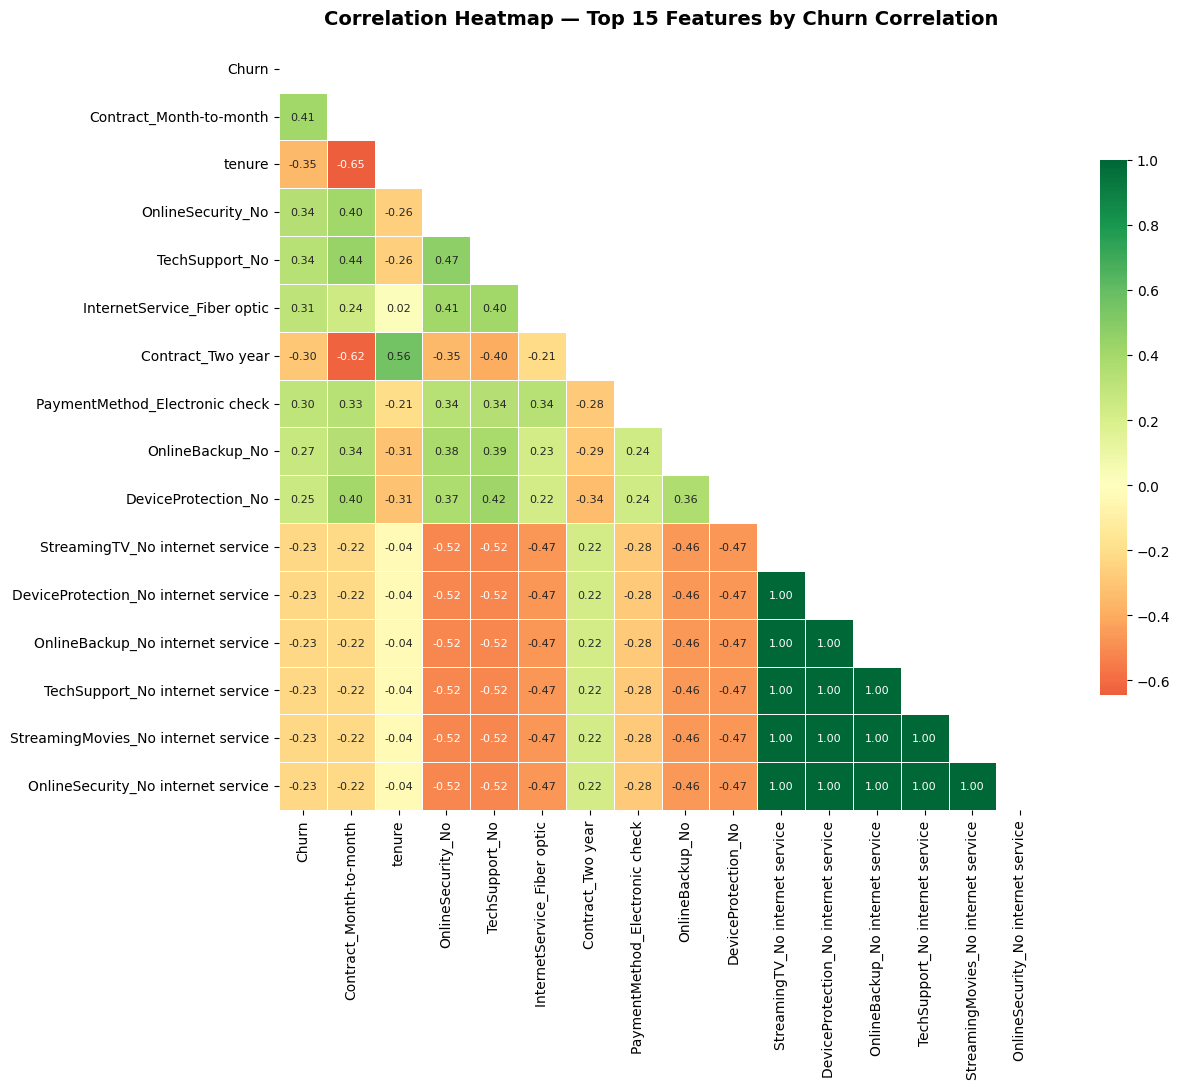


 Top 10 Features Correlated with Churn:
   Increases churn risk → Contract_Month-to-month                 : +0.4051
   Decreases churn risk → tenure                                  : -0.3522
   Increases churn risk → OnlineSecurity_No                       : +0.3426
   Increases churn risk → TechSupport_No                          : +0.3373
   Increases churn risk → InternetService_Fiber optic             : +0.3080
   Decreases churn risk → Contract_Two year                       : -0.3023
   Increases churn risk → PaymentMethod_Electronic check          : +0.3019
   Increases churn risk → OnlineBackup_No                         : +0.2680
   Increases churn risk → DeviceProtection_No                     : +0.2525
   Decreases churn risk → OnlineSecurity_No internet service      : -0.2279


In [16]:
# Correlation Heatmap
top_features = df_encoded.corr()['Churn'].abs().sort_values(ascending=False).head(16).index.tolist()
corr_subset  = df_encoded[top_features].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top 15 Features by Churn Correlation',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with Churn
churn_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False).head(10)
print('\n Top 10 Features Correlated with Churn:')
for feat, val in churn_corr.items():
    direction = ' Increases' if val > 0 else ' Decreases'
    print(f'  {direction} churn risk → {feat:<40}: {val:+.4f}')
    


#### 5. Handle Class Imbalance + Train-Test Split



Problem: 73.5% Stayed vs 26.5% Churned — model will be biased toward majority class

Solution: Oversample the minority class (Churned) in the training set only


In [17]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\n Train-Test Split (80/20 Stratified):')
print(f'   Training: {X_train.shape[0]:,} rows | Stayed={( y_train==0).sum():,} | Churned={(y_train==1).sum():,}')
print(f'   Testing : {X_test.shape[0]:,}  rows | Stayed={(y_test==0).sum():,}  | Churned={(y_test==1).sum():,}')

# Oversampling — minority class in training set
X_train_combined = pd.concat([X_train, y_train], axis=1)
stayed  = X_train_combined[X_train_combined['Churn'] == 0]
churned = X_train_combined[X_train_combined['Churn'] == 1]

churned_upsampled = resample(churned, replace=True,
                              n_samples=len(stayed), random_state=42)
train_balanced = pd.concat([stayed, churned_upsampled])
X_train_bal = train_balanced.drop(columns=['Churn'])
y_train_bal  = train_balanced['Churn']

print(f'\n After Oversampling (training set only):')
print(f'   Stayed : {(y_train_bal==0).sum():,} | Churned: {(y_train_bal==1).sum():,}')
print(f'   Balance: 50% / 50%')

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)
print('\n StandardScaler applied (for Logistic Regression)')


Feature matrix X: (7043, 38)
Target vector  y: (7043,)

 Train-Test Split (80/20 Stratified):
   Training: 5,634 rows | Stayed=4,139 | Churned=1,495
   Testing : 1,409  rows | Stayed=1,035  | Churned=374

 After Oversampling (training set only):
   Stayed : 4,139 | Churned: 4,139
   Balance: 50% / 50%

 StandardScaler applied (for Logistic Regression)


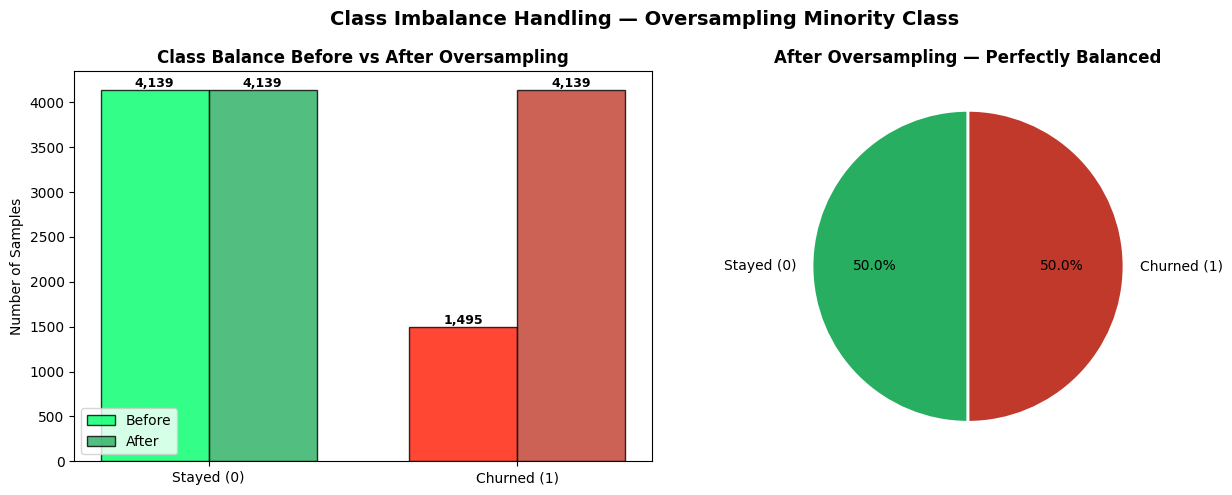

In [18]:
# Visualize class balance before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

before_vals = [(y_train==0).sum(), (y_train==1).sum()]
after_vals  = [(y_train_bal==0).sum(), (y_train_bal==1).sum()]
labels = ['Stayed (0)', 'Churned (1)']
x = np.arange(len(labels))
width = 0.35

b1 = axes[0].bar(x - width/2, before_vals, width, label='Before', color=["#00ff6a", "#ff1900"], edgecolor='black', alpha=0.8)
b2 = axes[0].bar(x + width/2, after_vals,  width, label='After',  color=['#27ae60','#c0392b'], edgecolor='black', alpha=0.8)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Class Balance Before vs After Oversampling', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].legend()

axes[1].pie(after_vals, labels=labels, colors=['#27ae60','#c0392b'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('After Oversampling — Perfectly Balanced', fontweight='bold')
plt.suptitle('Class Imbalance Handling — Oversampling Minority Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



#### 6. Train 4 Machine Learning Models


The model used here are Logistic Regression, Decision Tree, Random Forest and Gradient Boosting

In [19]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}
trained_models = {}

print(' Training Models...')

for name, model in models.items():
    print(f'\n   {name}...')
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train_bal)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'y_pred': y_pred, 'y_prob': y_prob
    }
    trained_models[name] = model
    r = results[name]
    print(f'      Acc={r["Accuracy"]} | Prec={r["Precision"]} | Rec={r["Recall"]} | F1={r["F1-Score"]} | AUC={r["ROC-AUC"]}')



 Training Models...

   Logistic Regression...
      Acc=0.7317 | Prec=0.4966 | Rec=0.7781 | F1=0.6062 | AUC=0.8412

   Decision Tree...
      Acc=0.7268 | Prec=0.4903 | Rec=0.746 | F1=0.5917 | AUC=0.7917

   Random Forest...
      Acc=0.7722 | Prec=0.5718 | Rec=0.5642 | F1=0.568 | AUC=0.8187

   Gradient Boosting...
      Acc=0.7495 | Prec=0.5186 | Rec=0.7834 | F1=0.6241 | AUC=0.8466


#### 7. Model Comparison & Evaluation


In [20]:
# Model Comparison Table
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['y_pred','y_prob']}
    for name, vals in results.items()
}).T.astype(float)

print('\n MODEL COMPARISON TABLE')
print('-' * 65)
print(metrics_df.sort_values('ROC-AUC', ascending=False).to_string())
best_auc = metrics_df['ROC-AUC'].idxmax()
best_f1  = metrics_df['F1-Score'].idxmax()

print(f'\n   Best by ROC-AUC : {best_auc}  ({metrics_df.loc[best_auc,"ROC-AUC"]:.4f})')
print(f'   Best by F1-Score: {best_f1}  ({metrics_df.loc[best_f1,"F1-Score"]:.4f})')



 MODEL COMPARISON TABLE
-----------------------------------------------------------------
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gradient Boosting      0.7495     0.5186  0.7834    0.6241   0.8466
Logistic Regression    0.7317     0.4966  0.7781    0.6062   0.8412
Random Forest          0.7722     0.5718  0.5642    0.5680   0.8187
Decision Tree          0.7268     0.4903  0.7460    0.5917   0.7917

   Best by ROC-AUC : Gradient Boosting  (0.8466)
   Best by F1-Score: Gradient Boosting  (0.6241)


Random Forest has the highest accuracy (77.2%) but the lowest ROC-AUC among tree models, showing that accuracy can be misleading. It tends to predict “no churn” more often, boosting accuracy but failing to identify actual churners.

In churn prediction, missing a churner is costly, so ROC-AUC is more important.
Gradient Boosting (AUC = 0.8466) performs better as it correctly ranks churners higher, making it the better choice for deployment.

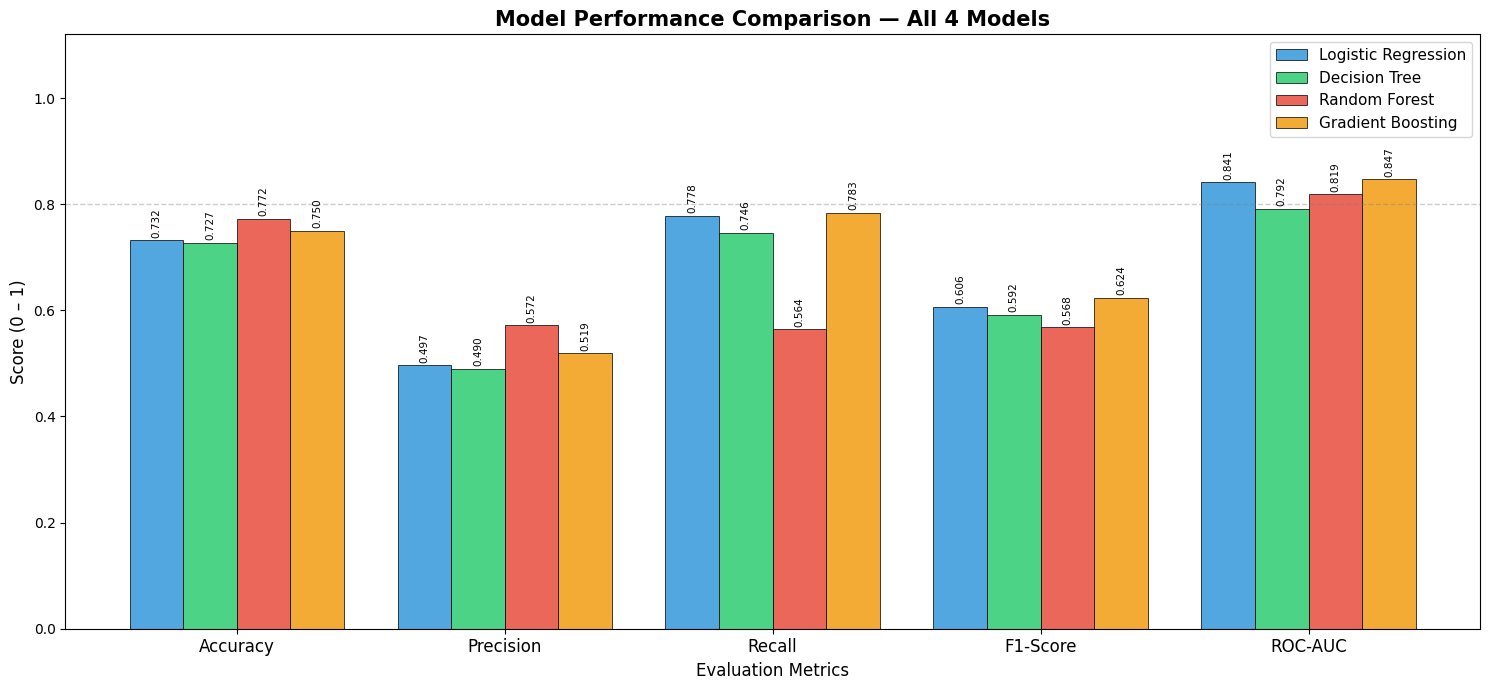

In [21]:
# Bar Chart Comparison
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_plot))
width = 0.2
COLORS = ['#3498db','#2ecc71','#e74c3c','#f39c12']


fig, ax = plt.subplots(figsize=(15, 7))
for i, (name, color) in enumerate(zip(results.keys(), COLORS)):
    vals = [results[name][m] for m in metrics_plot]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=color, alpha=0.85, edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)
ax.set_xlabel('Evaluation Metrics', fontsize=12)
ax.set_ylabel('Score (0 – 1)', fontsize=12)
ax.set_title('Model Performance Comparison — All 4 Models', fontsize=15, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_plot, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1, label='0.8 reference')
plt.tight_layout()
plt.show()


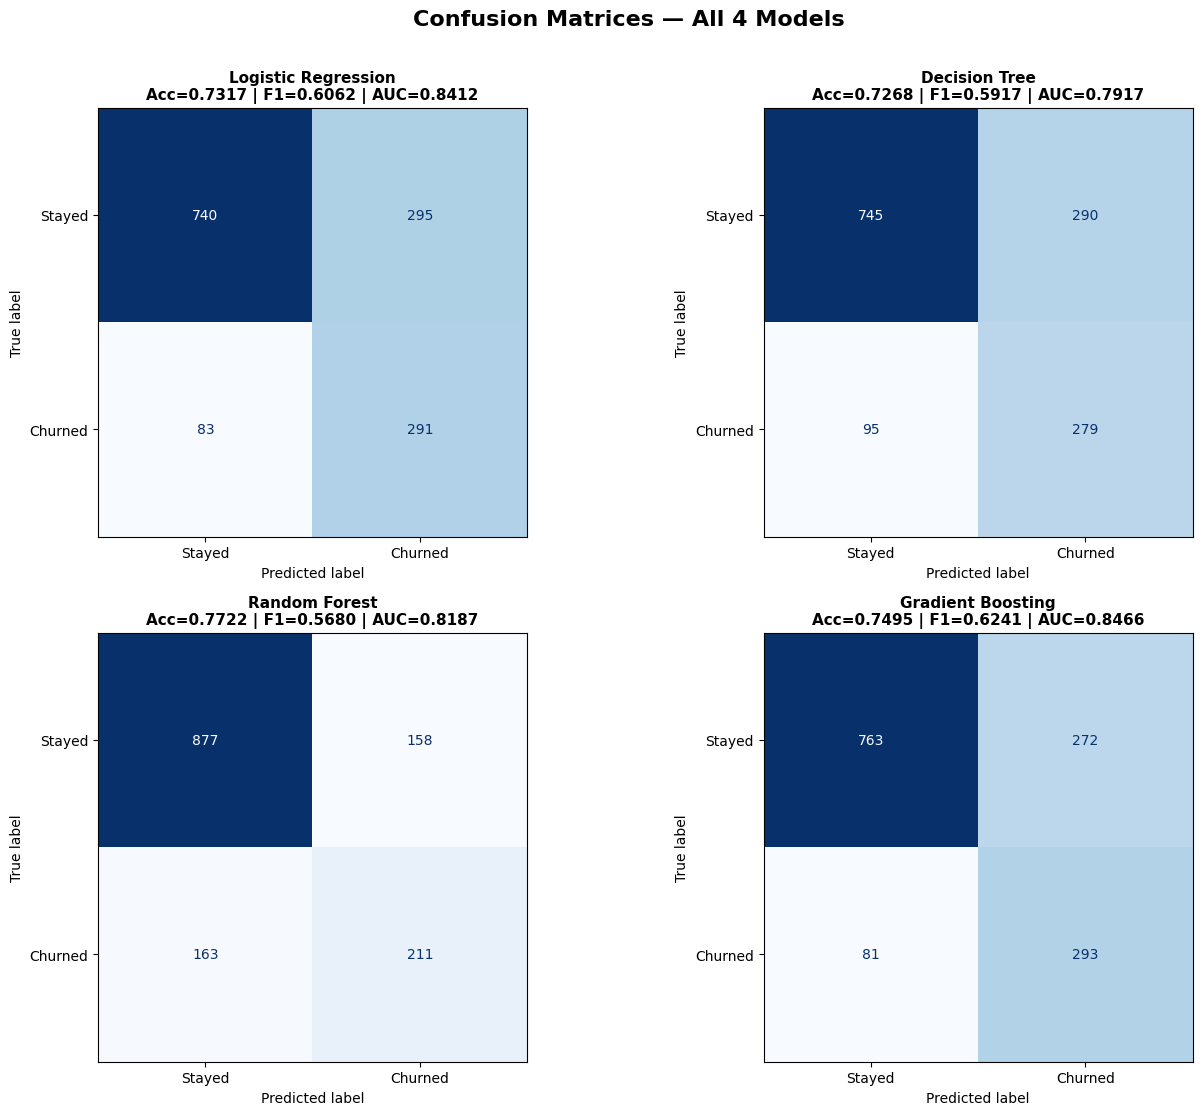

In [22]:
# Confusion Matrices — All 4 Models
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
for i, (name, vals) in enumerate(results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(
        f'{name}\nAcc={vals["Accuracy"]:.4f} | F1={vals["F1-Score"]:.4f} | AUC={vals["ROC-AUC"]:.4f}',
        fontweight='bold', fontsize=11)
plt.suptitle('Confusion Matrices — All 4 Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


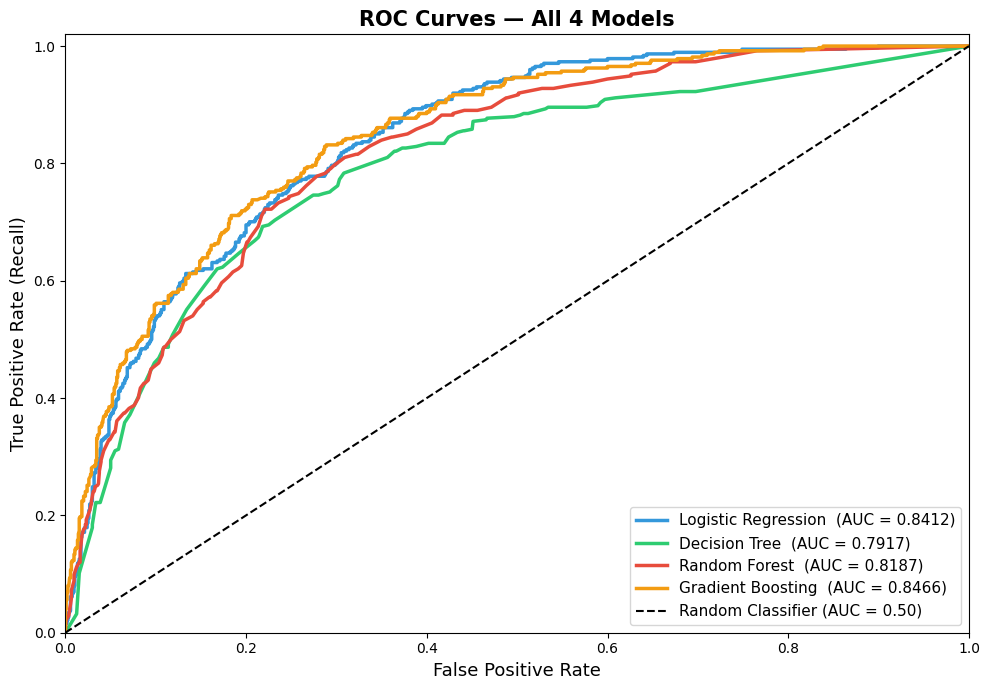

In [23]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))
for (name, vals), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
    ax.plot(fpr, tpr, lw=2.5, label=f'{name}  (AUC = {vals["ROC-AUC"]:.4f})', color=color)
ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curves — All 4 Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()


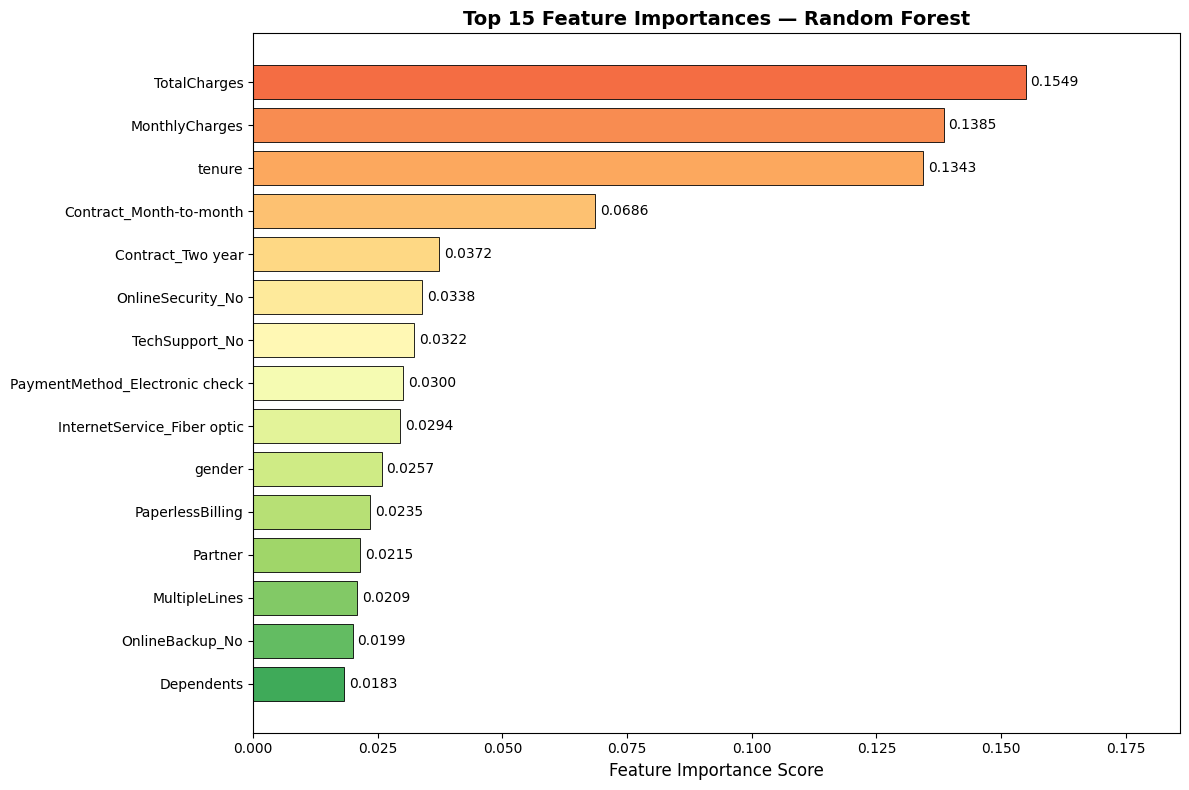


Top 5 Churn Predictors:
   → TotalCharges: 0.1549
   → MonthlyCharges: 0.1385
   → tenure: 0.1343
   → Contract_Month-to-month: 0.0686
   → Contract_Two year: 0.0372


In [24]:
# Feature Importance — Random Forest
rf_model = trained_models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train_bal.columns)
feat_imp_top = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 8))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(feat_imp_top)))[::-1]
bars = ax.barh(feat_imp_top.index[::-1], feat_imp_top.values[::-1],
               color=colors_fi, edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, feat_imp_top.values[::-1]):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlim(0, feat_imp_top.max()*1.2)
plt.tight_layout()
plt.show()

print('\nTop 5 Churn Predictors:')
for feat, imp in feat_imp_top.head(5).items():
    print(f'   → {feat}: {imp:.4f}')
    


In [ ]:
# Classification Reports — Separate cells to avoid truncation
print('\nCLASSIFICATION REPORTS — ALL 4 MODELS')
for name, vals in results.items():
    print(f'\n{"═"*58}')
    print(f'  {name}')
    print(f'{"═"*58}')
    print(classification_report(y_test, vals['y_pred'],
                                target_names=['Stayed', 'Churned']))
    


CLASSIFICATION REPORTS — ALL 4 MODELS

══════════════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.90      0.71      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409


══════════════════════════════════════════════════════════
  Decision Tree
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.89      0.72      0.79      1035
     Churned       0.49      0.75      0.59       374

    accuracy                           0.73      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.73      0.74      1409


══════════════════════════════

#### 8. Rule-Based Churn Logic


#### Rules Definition
The model is based on 6 key rules:

| Rule | Condition | Reason |
|------|----------|--------|
| Contract Type | Month-to-month | Customers without long-term commitment are more likely to leave |
| Tenure | Less than 12 months | New customers have not yet built loyalty |
| Monthly Charges | Greater than 70 | High cost increases churn probability |
| Internet Service | Fiber optic | Observed higher churn rate among fiber users |
| Payment Method | Electronic check | This method shows highest churn trends |
| Tech Support | No (with internet service) | Lack of support leads to dissatisfaction |


#### Scoring 

Each satisfied condition adds 1 point to the customer's risk score.
- Score ≥ 3 → High Risk → Predict Churn (1)
- Score = 2 → Medium Risk → Predict No Churn (0, monitor)
- Score ≤ 1 → Low Risk → Predict No Churn (0)


In [27]:
df_rules = df_clean.copy()

def rule_based_churn(row):
    score = 0
    flags = []

    # Rule 1: Contract Type
    if row['Contract'] == 'Month-to-month':
        score += 1
        flags.append('MonthToMonth')

    # Rule 2: Tenure
    if row['tenure'] < 12:
        score += 1
        flags.append('LowTenure')

    # Rule 3: Monthly Charges
    if row['MonthlyCharges'] > 70:
        score += 1
        flags.append('HighCharges')

    # Rule 4: Internet Service
    if row['InternetService'] == 'Fiber optic':
        score += 1
        flags.append('FiberOptic')

    # Rule 5: Payment Method
    if row['PaymentMethod'] == 'Electronic check':
        score += 1
        flags.append('ElectronicCheck')

    # Rule 6: Tech Support
    if row['TechSupport'] == 'No' and row['InternetService'] != 'No':
        score += 1
        flags.append('NoTechSupport')

    # Risk Classification
    if score >= 3:
        return 1, 'HIGH', score, '|'.join(flags)
    elif score == 2:
        return 0, 'MEDIUM', score, '|'.join(flags)
    else:
        return 0, 'LOW', score, '|'.join(flags)

In [42]:
rule_results = df_rules.apply(rule_based_churn, axis=1)

df_rules['Rule_Pred']  = [r[0] for r in rule_results]
df_rules['Risk_Level'] = [r[1] for r in rule_results]
df_rules['Risk_Score'] = [r[2] for r in rule_results]
df_rules['Risk_Flags'] = [r[3] for r in rule_results]


In [ ]:
y_true = df_clean['Churn']
y_pred = df_rules['Rule_Pred']

rule_acc  = accuracy_score(y_true, y_pred)
rule_prec = precision_score(y_true, y_pred)
rule_rec  = recall_score(y_true, y_pred)
rule_f1   = f1_score(y_true, y_pred)

print("\nRule-Based Model Performance")
print(f"Accuracy : {rule_acc:.4f}")
print(f"Precision: {rule_prec:.4f}")
print(f"Recall   : {rule_rec:.4f}")
print(f"F1 Score : {rule_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Rule-Based Model Performance
Accuracy : 0.6842
Precision: 0.4493
Recall   : 0.8411
F1 Score : 0.5857

 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.63      0.74      5174
           1       0.45      0.84      0.59      1869

    accuracy                           0.68      7043
   macro avg       0.68      0.73      0.67      7043
weighted avg       0.79      0.68      0.70      7043



In [44]:
risk_counts = df_rules['Risk_Level'].value_counts()

print("\n Risk Distribution:")
for level in ['HIGH', 'MEDIUM', 'LOW']:
    val = risk_counts.get(level, 0)
    print(f"{level}: {val} ({val/len(df_rules)*100:.1f}%)")


 Risk Distribution:
HIGH: 3499 (49.7%)
MEDIUM: 1340 (19.0%)
LOW: 2204 (31.3%)


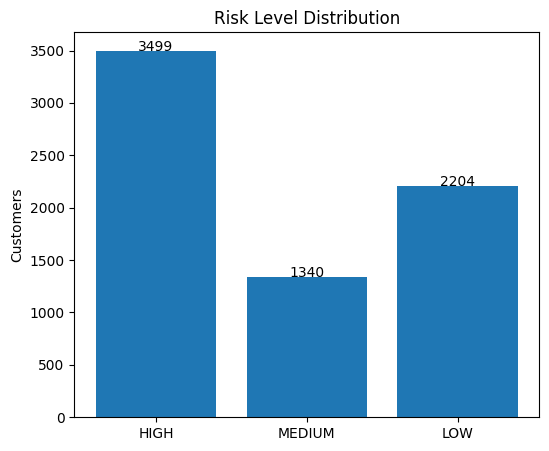

In [45]:
risk_order = ['HIGH', 'MEDIUM', 'LOW']
values = [risk_counts.get(r, 0) for r in risk_order]

plt.figure(figsize=(6,5))
bars = plt.bar(risk_order, values)

for bar, val in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
             str(val), ha='center')

plt.title("Risk Level Distribution")
plt.ylabel("Customers")
plt.show()

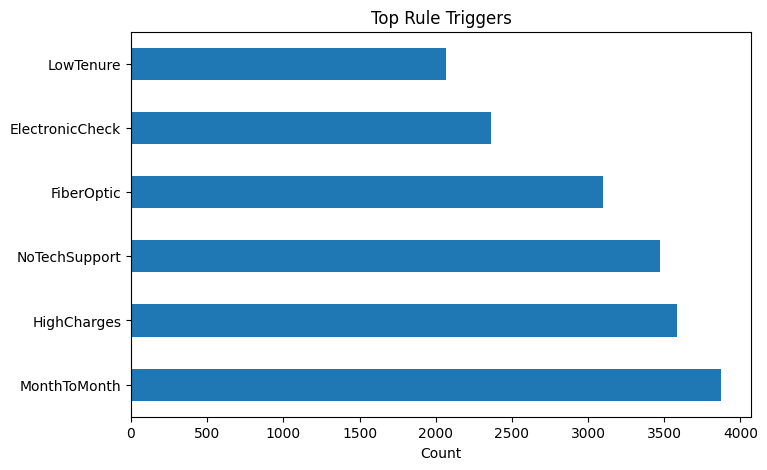

In [46]:
all_flags = '|'.join(df_rules['Risk_Flags']).split('|')
flag_freq = pd.Series(all_flags).value_counts()

plt.figure(figsize=(8,5))
flag_freq.head(6).plot(kind='barh')

plt.title("Top Rule Triggers")
plt.xlabel("Count")
plt.show()

In [47]:
print("\n Sample High-Risk Customers:")
print(df_rules[df_rules['Risk_Level']=='HIGH'][[
    'tenure','Contract','MonthlyCharges',
    'InternetService','PaymentMethod',
    'TechSupport','Risk_Score','Risk_Flags','Churn'
]].head())


 Sample High-Risk Customers:
   tenure        Contract  MonthlyCharges InternetService  \
0       1  Month-to-month           29.85             DSL   
2       2  Month-to-month           53.85             DSL   
4       2  Month-to-month           70.70     Fiber optic   
5       8  Month-to-month           99.65     Fiber optic   
6      22  Month-to-month           89.10     Fiber optic   

             PaymentMethod TechSupport  Risk_Score  \
0         Electronic check          No           4   
2             Mailed check          No           3   
4         Electronic check          No           6   
5         Electronic check          No           6   
6  Credit card (automatic)          No           4   

                                          Risk_Flags  Churn  
0  MonthToMonth|LowTenure|ElectronicCheck|NoTechS...      0  
2               MonthToMonth|LowTenure|NoTechSupport      1  
4  MonthToMonth|LowTenure|HighCharges|FiberOptic|...      1  
5  MonthToMonth|LowTenure|High

#### 9. Which Model is Best? — Final Verdict


In [48]:
# Final Summary
print('       TELCO CUSTOMER CHURN PREDICTION — SUMMARY')
print(f'  Dataset : IBM Telco | {df.shape[0]:,} customers | 20 features')
print(f'  Churn Rate: {df_clean["Churn"].mean()*100:.1f}%  (realistic imbalanced data)')
print(f'  Preprocessing: Missing values fixed, Encoded, Oversampled')
print()
print('  ML Models Trained & Compared:')
for i,(name,vals) in enumerate(sorted(results.items(), key=lambda x:-x[1]['ROC-AUC']),1):
    print(f'  {i}. {name:<25} F1={vals["F1-Score"]:.4f} | AUC={vals["ROC-AUC"]:.4f}')
print()
print(f'  Rule-Based System:           F1={rule_f1:.4f} | Recall={rule_rec:.4f} (interpretable)')
print()
best = max(results, key=lambda n: results[n]['ROC-AUC'])
print(f'   BEST MODEL: {best}')
print(f'     Reason: Highest ROC-AUC ({results[best]["ROC-AUC"]}) + F1 ({results[best]["F1-Score"]})')
print(f'     Best balance of Precision & Recall for real-world churn detection')

metrics_df_export = metrics_df.copy()
metrics_df_export.loc['Rule-Based Logic'] = [rule_acc, rule_prec, rule_rec, rule_f1, None]
metrics_df_export.round(4).to_csv('model_comparison_results.csv')
df_rules[df_rules['Risk_Level']=='HIGH'].to_csv('high_risk_customers.csv', index=False)
print('\n Results saved: model_comparison_results.csv')
print(' High-risk list saved: high_risk_customers.csv')

       TELCO CUSTOMER CHURN PREDICTION — SUMMARY
  Dataset : IBM Telco | 7,043 customers | 20 features
  Churn Rate: 26.5%  (realistic imbalanced data)
  Preprocessing: Missing values fixed, Encoded, Oversampled

  ML Models Trained & Compared:


TypeError: tuple indices must be integers or slices, not str


#### Final Results Table

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|-------|----------|-----------|--------|----------|----------|
| Logistic Regression | 0.7317 | 0.4966 | 0.7781 | 0.6062 | 0.8412 |
| Decision Tree | 0.7268 | 0.4903 | 0.7460 | 0.5917 | 0.7917 |
| Random Forest | 0.7722 | 0.5718 | 0.5642 | 0.5680 | 0.8187 |
| **Gradient Boosting** | 0.7495 | 0.5186 | **0.7834** | **0.6241** | **0.8466** |
| Rule-Based Logic | 0.6842 | 0.4493 | 0.8411 | 0.5857 | N/A |
